In [17]:
import numpy as np
import cv2 
import matplotlib.pyplot as plt
import os
from tqdm.notebook import tqdm
from sklearn.cluster import DBSCAN, OPTICS
import pandas as pd
from scipy.ndimage import sobel, uniform_filter1d
import scipy
import xarray as xr
import datetime
import time
from utils import *

plt.rcParams['image.origin'] = 'lower'
plt.rcParams['image.cmap'] = 'gray'

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
dir = '/Users/mleclair/phd/code/dunex/data/argus'
mission_32 = 'ArgusFF_20211013T170100Z_RectifiedVideo.avi'
mission_31 = 'ArgusFF_20211013T163100Z_RectifiedVideo.avi'
mission_69 = 'ArgusFF_20211028T170100Z_RectifiedVideo.avi'
mission_59 = 'ArgusFF_20211026T160100Z_RectifiedVideo.avi'
test = 'ArgusFF_20211028T140100Z_RectifiedVideo.avi'

In [84]:
good_data_slices = {
    'ArgusFF_20211028T140100Z_RectifiedVideo.avi' : 
        {
            'times': [(2000,3000)],
            'missions': [66, 67],
        },
    'ArgusFF_20211013T170100Z_RectifiedVideo.avi' :
        {
            'times': [(0, 275)],
            'missions': [32],
        },
    'ArgusFF_20211013T163100Z_RectifiedVideo.avi' :
        {
            'times': [(0, 120)] ,
            'missions': [31],
        },
    'ArgusFF_20211028T170100Z_RectifiedVideo.avi' :
        {
            'times': [(2900, 3050)],
            'missions': [69],
        },
    'ArgusFF_20211026T160100Z_RectifiedVideo.avi' :
        {
            'times': [(2600, 3000)],
            'missions': [59],
        },
}


for file, times in good_data_slices.items():
    good_data_seconds = 0
    for start, end in times['times']:
        good_data_seconds += (end - start) / 2 # fps
    print(file, good_data_seconds/60, 'minutes')

ArgusFF_20211028T140100Z_RectifiedVideo.avi 8.333333333333334 minutes
ArgusFF_20211013T170100Z_RectifiedVideo.avi 2.2916666666666665 minutes
ArgusFF_20211013T163100Z_RectifiedVideo.avi 1.0 minutes
ArgusFF_20211028T170100Z_RectifiedVideo.avi 1.25 minutes
ArgusFF_20211026T160100Z_RectifiedVideo.avi 3.3333333333333335 minutes


: 

1.92mb per timestack


Building Timestack:   0%|          | 0/300 [00:00<?, ?it/s]

Building Timestack: 100%|██████████| 300/300 [00:00<00:00, 507.43it/s]


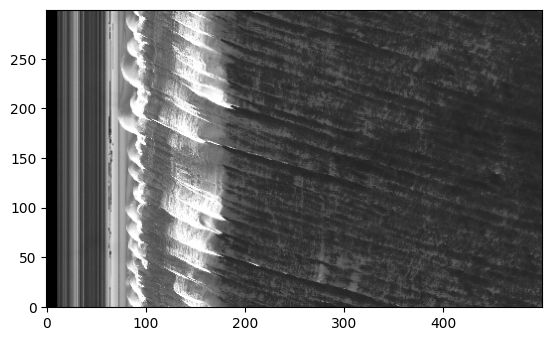

In [22]:
file = mission_32
N, H, W, FPS = get_video_shape(os.path.join(dir, file))
timestack = make_timestack(dir, file, 300)
N = min(N, len(timestack))
plt.imshow(timestack[:, 500, :])

100%|██████████| 300/300 [00:07<00:00, 40.09it/s]


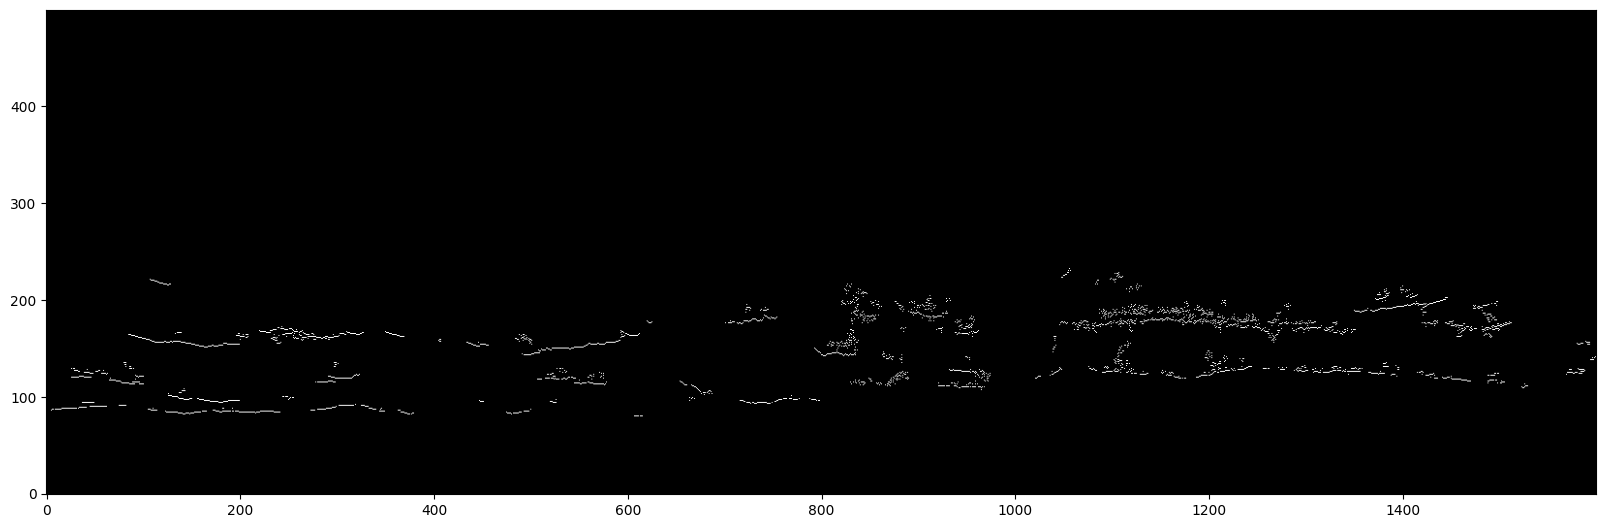

In [26]:
# original
b =    np.zeros_like(timestack[:N, :, :])
bb =   np.zeros_like(timestack[:N, :, :])
bbb =  np.zeros_like(timestack[:N, :, :])
bbbb = np.zeros_like(timestack[:N, :, :])

# This takes the 95th percenetile of the image.
# of a backwards differenced image, and filters for leading edges & then clusters.
# The diff imaige is from Yoo '10 and Lipmann & Holmann '89
for i in tqdm(range(1600)):
    dtimestack = timestack[:, i] #- 0.5 * ((timestack[1:-1, i]) + (timestack[:-2, i]))
    binary_image = detect_leading_edges(dtimestack >= np.percentile(dtimestack, 95), 0)
    b[:, i, :] = binary_image
    bb[:, i, :] = remove_loose_pixels_not_in_line(binary_image, min_line_length=3, eps=5, min_samples=5)

# Again take the rising edge in space (this shouldn't be necessary), and then filter on space (DBSCAN)    
for i in tqdm(range(len(b))):
    bbb[i] = detect_leading_edges(bb[i], 1)
    bbbb[i] = remove_loose_pixels_not_in_line(bbb[i], min_line_length=3, eps=3, min_samples=5)
    
plt.figure(figsize=(20, 10))
plt.imshow(bbbb[1].T)
# plt.xlim(300, 600)
# plt.ylim(100, 300)

100%|██████████| 300/300 [00:12<00:00, 23.40it/s]


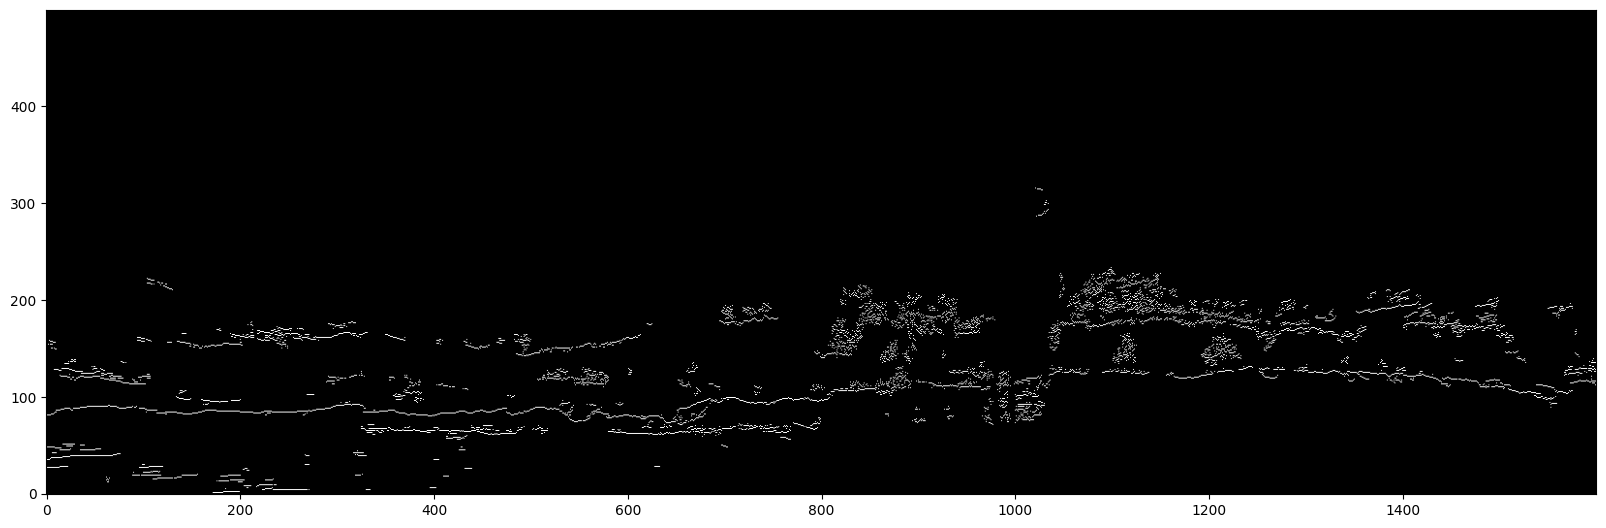

In [24]:
# new
b =    np.zeros_like(timestack[:N, :, :])
bb =   np.zeros_like(timestack[:N, :, :])
bbb =  np.zeros_like(timestack[:N, :, :])
bbbb = np.zeros_like(timestack[:N, :, :])

# This takes the 95th percenetile of the image.
# of a backwards differenced image, and filters for leading edges & then clusters.
# The diff imaige is from Yoo '10 and Lipmann & Holmann '89
for i in tqdm(range(1600)):
    # dtimestack = timestack[:, i] #- 0.5 * ((timestack[1:-1, i]) + (timestack[:-2, i]))
    # binary_image = detect_leading_edges(dtimestack >= np.percentile(dtimestack, 95), 0)
    # b[:, i, :] = binary_image
    bb[:-1, i, :] = remove_loose_pixels_not_in_line(
                        detect_leading_edges(
                            timestack[:, i].T >= np.percentile(timestack[:, i], 95, axis=1))[:, :-1] | 
                        remove_loose_pixels((timestack[1:, i] - timestack[:-1, i]).T > np.percentile((timestack[1:, i] - timestack[:-1, 10]).T, 99, axis=0), 2)
                    , min_line_length=3, eps=5, min_samples=5).T

# Again take the rising edge in space (this shouldn't be necessary), and then filter on space (DBSCAN)    
for i in tqdm(range(len(b))):
    bbb[i] = detect_leading_edges(bb[i], 1)
    bbbb[i] = remove_loose_pixels_not_in_line(bbb[i], min_line_length=3, eps=3, min_samples=5)
    
plt.figure(figsize=(20, 10))
plt.imshow(bbbb[1].T)
# plt.xlim(300, 600)
# plt.ylim(100, 300)



In [183]:
from utils import *
argus_sequence_to_xarray(timestack[0:4], start=1).size

3.2

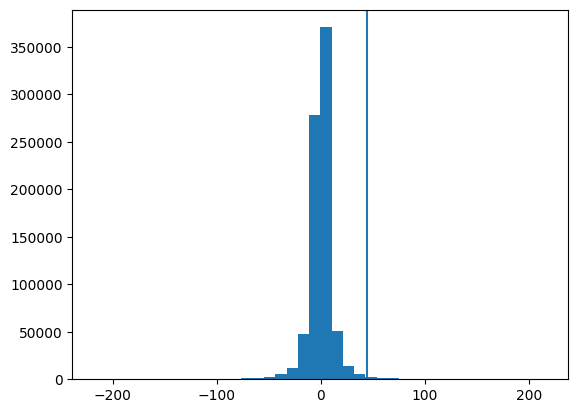

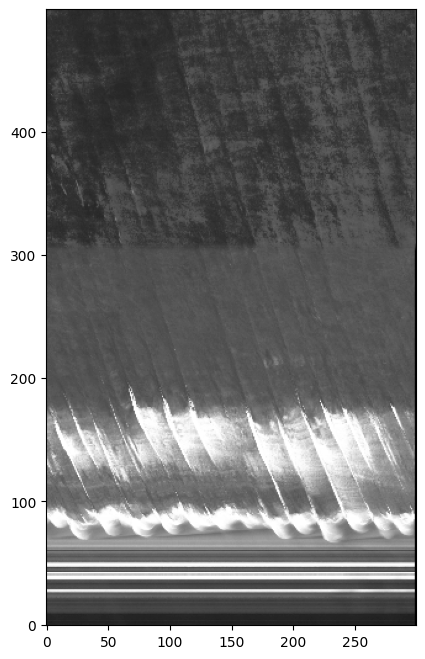

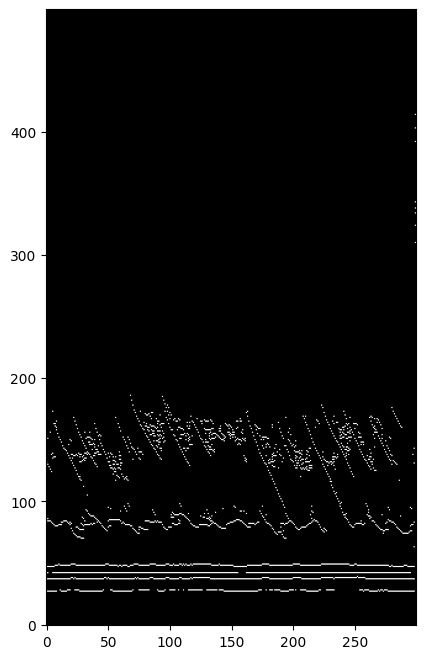

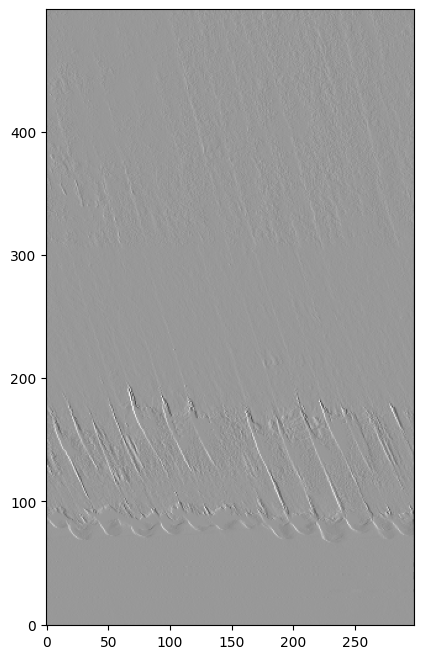

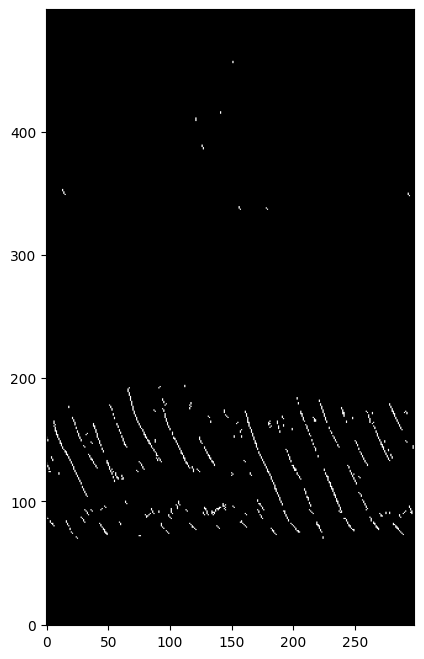

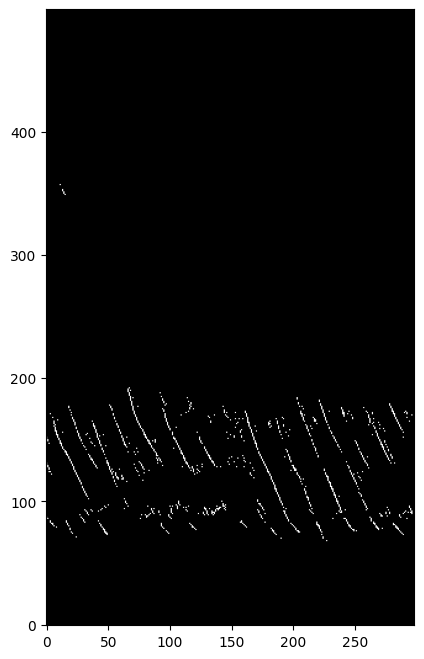

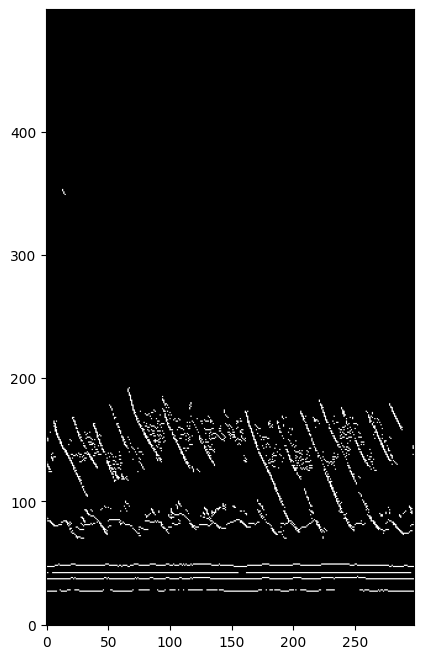

In [25]:
plt.hist((timestack[1] - timestack[0]).flatten(), bins=40)
plt.axvline(np.percentile((timestack[1] - timestack[0]).flatten(), 99))
plt.figure(figsize=(30, 8))
plt.imshow(timestack[:, 10].T)
plt.figure(figsize=(30, 8))
plt.imshow(
    detect_leading_edges(
        # ndi.binary_closing(
            timestack[:, 10].T >= np.percentile(timestack[:, 10], 95, axis=1)
            # , iterations=1)
        )
)
plt.figure(figsize=(30, 8))
plt.imshow((timestack[1:, 10] - timestack[:-1, 10]).T)
plt.figure(figsize=(30, 8))
plt.imshow(
        remove_loose_pixels((timestack[1:, 10] - timestack[:-1, 10]).T > np.percentile((timestack[1:, 10] - timestack[:-1, 10]).T, 99, axis=0), 2))
plt.figure(figsize=(30, 8))
plt.imshow(
    remove_loose_pixels_not_in_line(
        (timestack[1:, 10] - timestack[:-1, 10]).T > np.percentile((timestack[1:, 10] - timestack[:-1, 10]).T, 99, axis=0),
    min_line_length=3, eps=5, min_samples=5))
plt.figure(figsize=(30, 8))
plt.imshow(
    remove_loose_pixels_not_in_line(
        detect_leading_edges(
            timestack[:, 10].T >= np.percentile(timestack[:, 10], 95, axis=1))[:, :-1] | 
        remove_loose_pixels((timestack[1:, 10] - timestack[:-1, 10]).T > np.percentile((timestack[1:, 10] - timestack[:-1, 10]).T, 99, axis=0), 2)
    , min_line_length=3, eps=5, min_samples=5)
)

(-74.7, 1678.7, -11.75, 334.75)

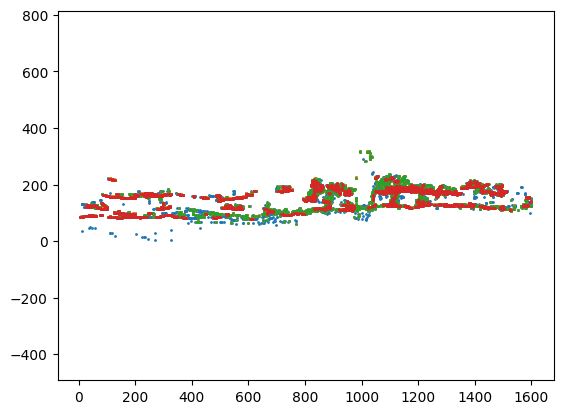

In [27]:
plt.scatter(*b[1].nonzero(),    s=1, label='timestack percent')
plt.scatter(*bb[1].nonzero(),   s=1, label='timestack leading')
plt.scatter(*bbb[1].nonzero(),  s=1, label='space leading')
plt.scatter(*bbbb[1].nonzero(), s=1, label='space line')

plt.axis('equal')

In [28]:
# Remove pixels less than 5 connected components
bbbbb = np.zeros_like(timestack[:N, :, :])

for i in tqdm(range(len(b))):
    bbbbb[i] = remove_loose_pixels(bbbb[i], 5)

100%|██████████| 300/300 [00:02<00:00, 109.02it/s]


Text(0.5, 1.0, 'ArgusFF_20211013T170100Z_RectifiedVideo.avi')

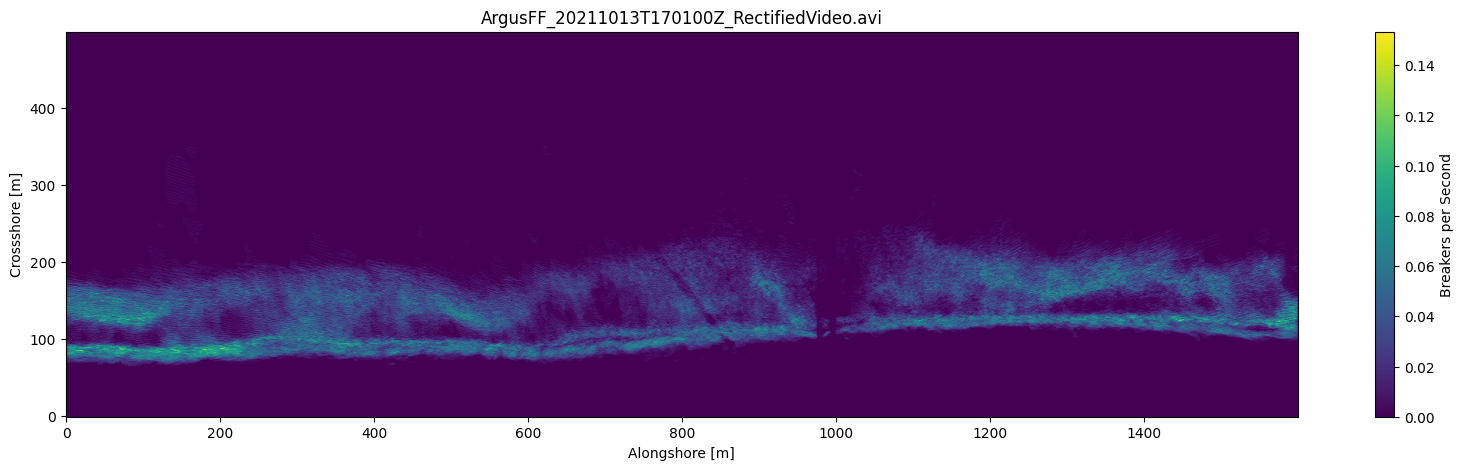

In [29]:
# This still shows spatial bias and 
plt.figure(figsize=(20, 5))
plt.imshow(bbbbb.sum(0).T/len(timestack)*FPS, cmap='viridis')
plt.xlabel('Alongshore [m]')
plt.ylabel('Crossshore [m]')
plt.colorbar(label='Breakers per Second')
plt.title(file)


In [31]:
breaker_labels = filter_and_label_spatiotemporal_propagation(bbbbb, min_size=6, time_window=3, space_window=5)

100%|██████████| 300/300 [01:33<00:00,  3.20it/s]


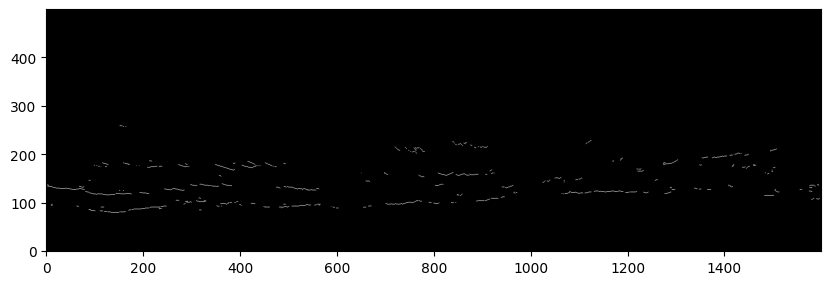

In [32]:
plt.figure(figsize=(10,30))
plt.imshow(breaker_labels[50].T > 0)

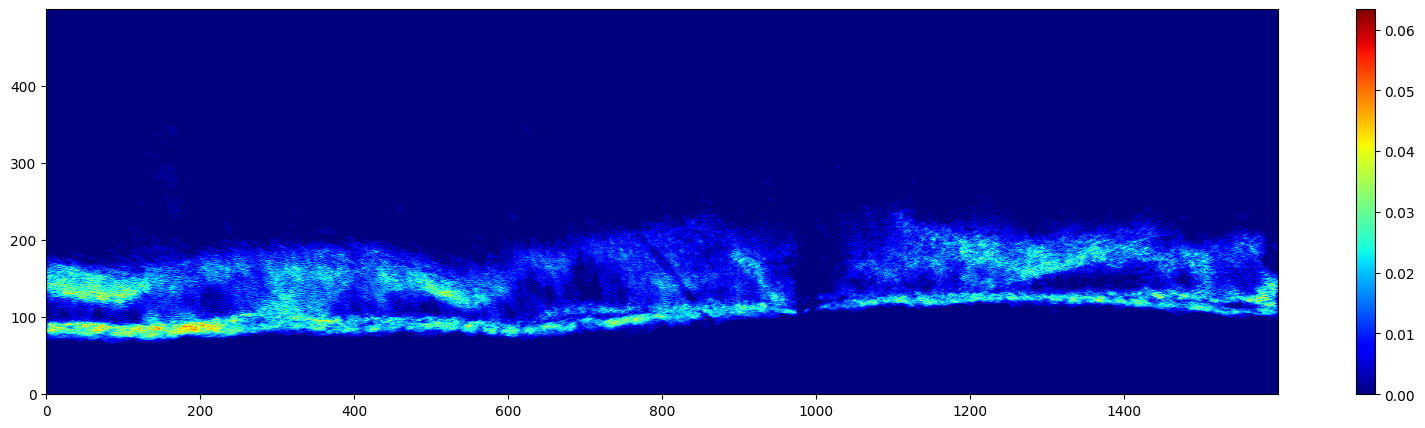

In [33]:
plt.figure(figsize=(20,5))
plt.imshow((breaker_labels > 0).sum(0).T/N, cmap='jet')
plt.colorbar()

In [ ]:
from utils import *
write_sequence_to_mp4(timestack[:5], 'test2.mp4', transpose=True, color=True)

  0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 5/5 [00:00<00:00, 91.89it/s]


In [45]:
fname = '32_filtered.mp4'
out = cv2.VideoWriter(fname, cv2.VideoWriter_fourcc(*'avc1'), FPS*5, (W, H), True)
def normalize(x, scale=255):
    x = (x - x.min())
    return (x/x.max() * scale).astype(np.uint8)

print(H, W)
for i in tqdm(range(2, len(b))):
    image = normalize(timestack[i])#normalize(timestack[i] - 0.5 * (timestack[i-1] + timestack[i-2]))
    # image = timestack[i]
    frame = np.stack((image,) * 3, axis=-1)
    # if np.any(b[i]!=0):
    #     frame[
    #         # ndi.binary_dilation(
    #             b[i]!=0
    #             # )
    #         ] = np.array([0, 0, 255])
    # frame[image>np.percentile(image, 99.5)] = np.array([255, 0, 0])
    # if np.any(breaker_labels[i]!=0):
    #     frame[
    #         ndi.binary_dilation(
    #             bbbb[i]!=0
    #         )
    #         ] = np.array([255, 0, 0])

    if np.any(breaker_labels[i] != 0):
        frame[ndi.binary_dilation(breaker_labels[i]!=0, iterations=2)] = np.array(([0, 0, 255]))

    out.write(np.flip(np.swapaxes(frame.astype(np.uint8), 0, 1), 0))
    # out.write(np.flip(np.swapaxes((breaker_labels[i]!=0).astype(np.uint8) * 255, 0, 1), 0))
        
out.release()
cv2.destroyAllWindows()


500 1600


  0%|          | 0/298 [00:00<?, ?it/s]

100%|██████████| 298/298 [00:08<00:00, 36.92it/s]


In [42]:
frame.shape

(1600, 500, 3)

In [46]:
import numpy as np
from scipy import stats

# Assuming breaker_labels and FPS are defined

# Get unique non-zero labels and their indices
unique_labels, inverse = np.unique(breaker_labels[breaker_labels != 0], return_inverse=True)

# Pre-compute all indices
indices = np.column_stack(np.nonzero(breaker_labels))


grouped_indices = [indices[inverse == i] for i in range(len(unique_labels))]


In [47]:
# Assuming 'indices' and 'inverse' are numpy arrays
sorted_indices = np.argsort(inverse)
sorted_inverse = inverse[sorted_indices]
sorted_values = indices[sorted_indices]

# Find the boundaries of each group
group_boundaries = np.concatenate(([0], np.nonzero(np.diff(sorted_inverse))[0] + 1, [len(inverse)]))

# Split the sorted values at these boundaries
grouped_indices = np.split(sorted_values, group_boundaries[1:-1])


In [48]:
L = []
C = []
COUNT = []
CROSS_SHORE = []
ALONG_SHORE = []

for group in tqdm(grouped_indices):
    if len(group) == 0:
        continue
    
    time = group[:, 0]
    along_shore = group[:, 1]
    cross_shore = group[:, 2]
    
    # Get unique times
    unique_times = sorted(np.unique(time))
    
    # Compute lengths and mean cross-shores in a vectorized way
    # TODO(@mleclair) This could be a more acurate crest length
    lengths = np.array([along_shore[time == t].ptp() for t in unique_times])
    mean_cross_shores = np.array([cross_shore[time == t].mean() for t in unique_times])
    
    L.append(np.max(lengths))
    C.append(np.diff(mean_cross_shores).mean() * FPS)
    COUNT.append(len(unique_times))
    CROSS_SHORE.append(cross_shore.mean())
    ALONG_SHORE.append(along_shore.mean())
    
L = np.array(L)
C = np.array(C)
COUNT = np.array(COUNT)
CROSS_SHORE = np.array(CROSS_SHORE)
ALONG_SHORE = np.array(ALONG_SHORE)

mask = (COUNT>4*FPS) 
C =                     C[mask]
L =                     L[mask]
CROSS_SHORE = CROSS_SHORE[mask]
ALONG_SHORE = ALONG_SHORE[mask]
COUNT =             COUNT[mask]

  0%|          | 0/77452 [00:00<?, ?it/s]

/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_18615/643765104.py:24: RuntimeWarning: Mean of empty slice.
  C.append(np.diff(mean_cross_shores).mean() * FPS)
/Users/mleclair/phd/code/.venv/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
100%|██████████| 77452/77452 [00:03<00:00, 19980.09it/s]


<>:26: SyntaxWarning: invalid escape sequence '\L'
<>:28: SyntaxWarning: invalid escape sequence '\L'
<>:26: SyntaxWarning: invalid escape sequence '\L'
<>:28: SyntaxWarning: invalid escape sequence '\L'
/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_18615/2110502237.py:26: SyntaxWarning: invalid escape sequence '\L'
  plt.title(f'$\Lambda(c)$ for argus {N/FPS/60}min data')
/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_18615/2110502237.py:28: SyntaxWarning: invalid escape sequence '\L'
  plt.ylabel('$\Lambda(c)$')
/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_18615/2110502237.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('c_bin')


(1e-06, 0.1)

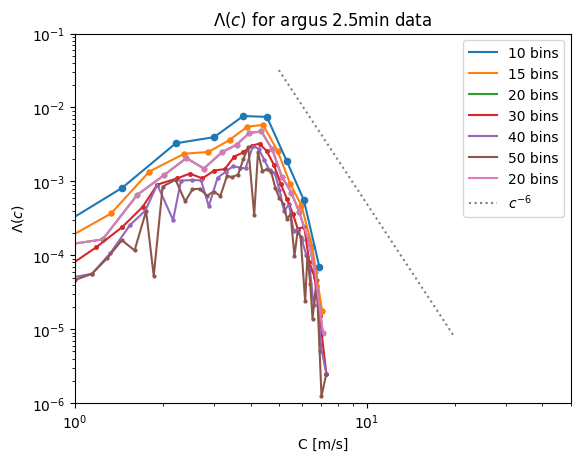

In [78]:
# From Jessup '05
# $\Lambda(c) = \frac{\Sigma_{(c, c+\delta c)L_i}}{A_s}

df = pd.DataFrame({
    'c': -C,  # X-axis data
    'L': L,   # Y-axis data
    'N': COUNT
})

# Create bins for X-axis data

for num_bins in [10, 15, 20, 30, 40, 50, 20]:
    df['c_bin'] = pd.cut(df['c'], bins=num_bins)

    grouped = df.groupby('c_bin')
    Lambda = grouped['L'].sum() / (W*H)

    c_centers = (grouped['c'].min() + grouped['c'].max()) / 2

    plt.loglog(c_centers, Lambda, label=f'{num_bins} bins')
    plt.scatter(c_centers, Lambda, s=200/num_bins)
    
c = np.linspace(5, 20)
plt.loglog(c, 500*c**-6, linestyle=':', label='$c^{-6}$')
plt.legend()
plt.title(f'$\Lambda(c)$ for argus {N/FPS/60}min data')
plt.xlabel('C [m/s]')
plt.ylabel('$\Lambda(c)$')
plt.xlim(1, 50)
plt.ylim(10e-7, 10e-2)

In [64]:
areas_with_breaking = ((breaker_labels != 0).sum(0) > 0)
breaking_area = areas_with_breaking.sum()
print("Fractional Area with Breaking:", areas_with_breaking.sum() / timestack.shape[1] / timestack.shape[2])
print(f"{(breaker_labels>0).sum() / breaking_area / N * FPS:.4f} breakers per second per Area with >0 breakers")

Fractional Area with Breaking: 0.409065
0.0147 breakers per second per Area with >0 breakers


0.0060 breakers per second of whole image [Argus RB]
0.0136 breakers per second of surf zone [Argus RB]


Text(0.5, 0, 'Along shore [m]')

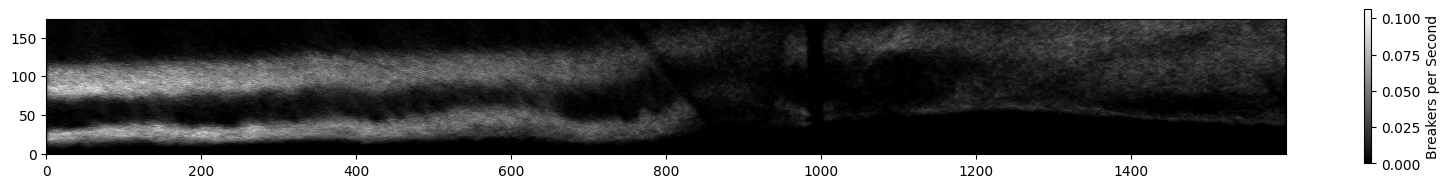

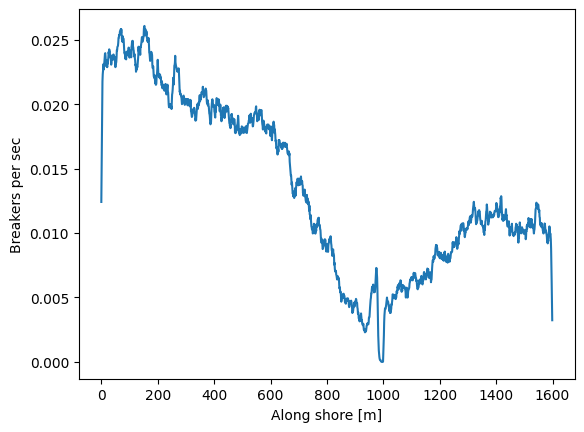

In [65]:
# Sliced to surfzone to see if it's closer?
breaking_rate = (breaker_labels!=0)[:, :, 65:240].sum(0)/N*FPS
breaking_rate_full = (breaker_labels!=0)[:, :, :].sum(0)/N*FPS
plt.figure(figsize=(20, 2))
plt.imshow(breaking_rate.T[:])
plt.colorbar(label='Breakers per Second')
print(f'{FPS / W / H / N  * (breaker_labels!=0).sum():.4f} breakers per second of whole image [Argus RB]')
print(f'{FPS / W / (240-65) / N  * (breaker_labels!=0)[:, :, 65:240].sum():.4f} breakers per second of surf zone [Argus RB]')
# print(FPS / W / H / N  * (breaker_labels!=0).sum(), ' breakers per second of surf zone')
plt.figure()
plt.plot(breaking_rate.mean(1))
plt.ylabel('Breakers per sec')
plt.xlabel('Along shore [m]')
# Suspiciously 1/2 of the turnover rate...

In [107]:
tunover_rate = R = np.trapz(c_centers * Lambda, c_centers)
print(f'{tunover_rate=:.4f} breakers per second average for scene 1st moment Lambda(c)')

tunover_rate=0.0220 breakers per second average for scene 1st moment Lambda(c)


## Inspecting the L-c distribution

Text(0, 0.5, 'L [m]')

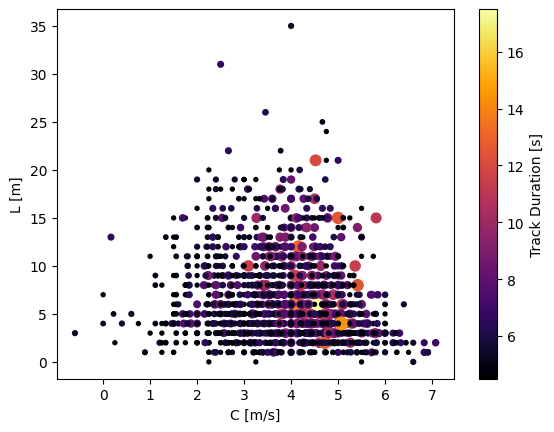

In [108]:
plt.scatter(-C, L, s=COUNT**2/10, c=COUNT/FPS, cmap='inferno')
plt.colorbar(label='Track Duration [s]')
plt.xlabel('C [m/s]')
plt.ylabel('L [m]')

Text(0, 0.5, 'L [m]')

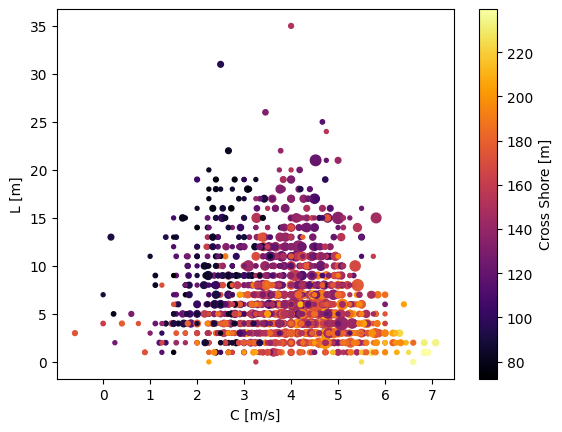

In [109]:
plt.scatter(-C, L, s=COUNT**2/10, c=CROSS_SHORE, cmap='inferno')
plt.colorbar(label='Cross Shore [m]')
plt.xlabel('C [m/s]')
plt.ylabel('L [m]')

Text(0, 0.5, 'L [m]')

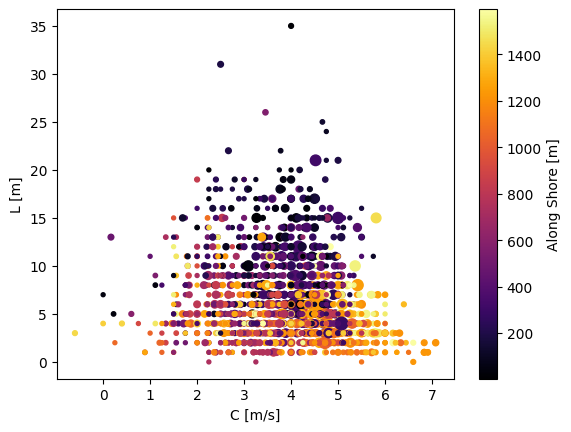

In [110]:
plt.scatter(-C, L, s=COUNT**2/10, c=ALONG_SHORE, cmap='inferno')
plt.colorbar(label='Along Shore [m]')
plt.xlabel('C [m/s]')
plt.ylabel('L [m]')

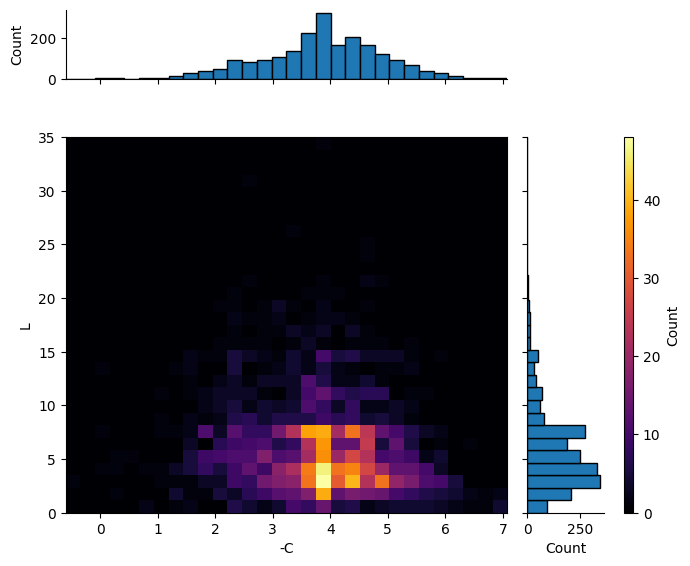

In [558]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

# Create a figure with custom gridspec
fig = plt.figure(figsize=(7, 6))
gs = GridSpec(5, 6, width_ratios=[1, 1, 1, 1, 0.8, 0.1], height_ratios=[0.8, 1, 1, 1, 0.1])

bins=30

# Top histogram for -C
ax_top = fig.add_subplot(gs[0, 0:4])
ax_top.hist(-C, bins=bins, edgecolor='black')
ax_top.set_ylabel('Count')
ax_top.tick_params(axis="x", labelbottom=False)

# Main 2D histogram
ax_main = fig.add_subplot(gs[1:4, 0:4], sharex=ax_top)
h = ax_main.hist2d(-C, L, bins=bins, cmap='inferno')
ax_main.set_xlabel('-C')
ax_main.set_ylabel('L')

# Right histogram for L
ax_right = fig.add_subplot(gs[1:4, 4], sharey=ax_main)
ax_right.hist(L, bins=bins, orientation='horizontal', edgecolor='black')
ax_right.set_xlabel('Count')
ax_right.tick_params(axis="y", labelleft=False)

# Colorbar
cbar_ax = fig.add_subplot(gs[1:4, 5])
plt.colorbar(h[3], cax=cbar_ax, label='Count')

# Remove top and right spines for top and right histograms
ax_top.spines['top'].set_visible(False)
ax_top.spines['right'].set_visible(False)
ax_right.spines['top'].set_visible(False)
ax_right.spines['right'].set_visible(False)

# Adjust the layout and display the plot
plt.tight_layout()
plt.show()

### Inspecting the spatial distribution of L-c 

It looks like there's Length bias correlated with the distance from the camera location (~1000m along shore).
The speeds in the swash are much lower (as expected)
No real signal in duration

/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_71275/1819380921.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.log10(COUNT/FPS*-C))
/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_71275/1819380921.py:1: RuntimeWarning: invalid value encountered in log10
  plt.plot(np.log10(COUNT/FPS*-C))


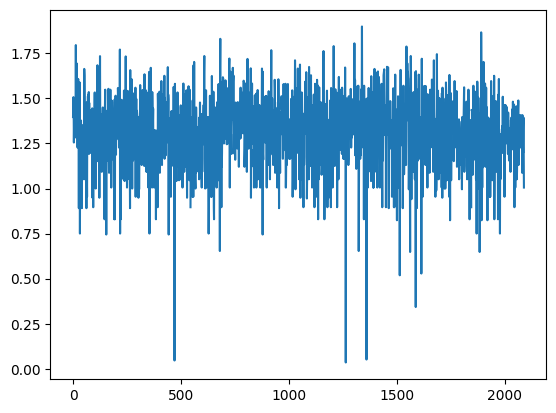

/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_30111/2231012779.py:3: RuntimeWarning: divide by zero encountered in log10
  s = axs[0].scatter(ALONG_SHORE, CROSS_SHORE, c=np.log10(L), s=5, cmap='jet')
/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_30111/2231012779.py:14: RuntimeWarning: divide by zero encountered in log10
  s, axs[2].scatter(ALONG_SHORE, CROSS_SHORE, c=np.log10(COUNT/FPS*-C), s=5, cmap='jet')
/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_30111/2231012779.py:14: RuntimeWarning: invalid value encountered in log10
  s, axs[2].scatter(ALONG_SHORE, CROSS_SHORE, c=np.log10(COUNT/FPS*-C), s=5, cmap='jet')


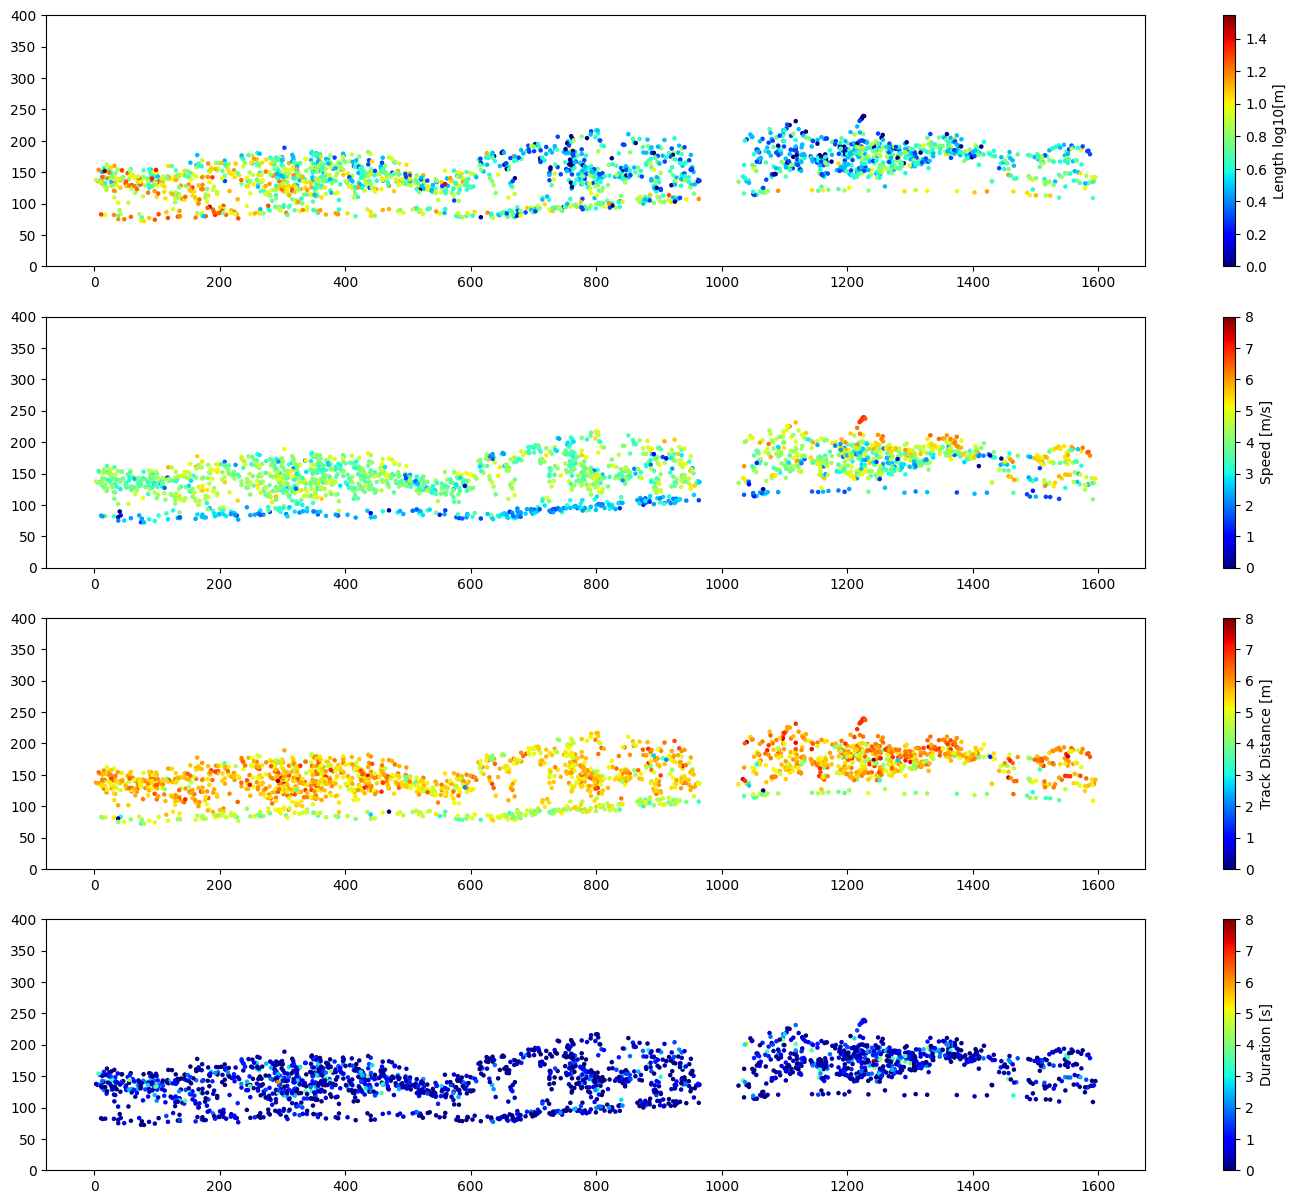

In [111]:
fig, axs = plt.subplots(4, 1, figsize=(20, 15))

s = axs[0].scatter(ALONG_SHORE, CROSS_SHORE, c=np.log10(L), s=5, cmap='jet')
axs[0].set_ylim(0, 400)
axs[0].set_aspect(1)
plt.colorbar(s, label='Length log10[m]', ax=axs[0])


s = axs[1].scatter(ALONG_SHORE, CROSS_SHORE, c=-C, s=5, cmap='jet', vmin=0, vmax=8)
axs[1].set_ylim(0, 400)
axs[1].set_aspect(1)
plt.colorbar(s, label='Speed [m/s]', ax=axs[1])

s, axs[2].scatter(ALONG_SHORE, CROSS_SHORE, c=np.log10(COUNT/FPS*-C), s=5, cmap='jet')
axs[2].set_ylim(0, 400)
axs[2].set_aspect(1)
plt.colorbar(s, label='Track Distance [m]', ax=axs[2])

s, axs[3].scatter(ALONG_SHORE, CROSS_SHORE, c=(COUNT/FPS), s=5, cmap='jet')
axs[3].set_ylim(0, 400)
axs[3].set_aspect(1)
plt.colorbar(s, label='Duration [s]', ax=axs[3])


slope=0.0078
intercept=2.4880
r=0.5201
p=0.00000000
se=0.0003


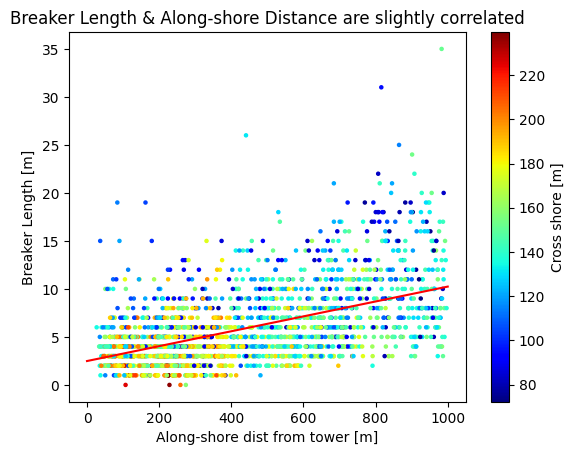

In [103]:
plt.scatter(np.abs(ALONG_SHORE - 1000), L, c=CROSS_SHORE, s=5, cmap='jet')
plt.xlabel('Along-shore dist from tower [m]')
plt.ylabel('Breaker Length [m]')
plt.colorbar(label='Cross shore [m]')
plt.title('Breaker Length & Along-shore Distance are slightly correlated')
slope, intercept, r, p, se = scipy.stats.linregress(np.abs(ALONG_SHORE - 1000), L)
x = np.linspace(0, 1000)
plt.plot(x, slope*x + intercept, c='r')
print(
f'''
{slope=:.4f}
{intercept=:.4f}
{r=:.4f}
{p=:.8f}
{se=:.4f}''')